20260501000000-240h-enfo-tf.bufr:   0%|          | 0.00/433k [00:00<?, ?B/s]

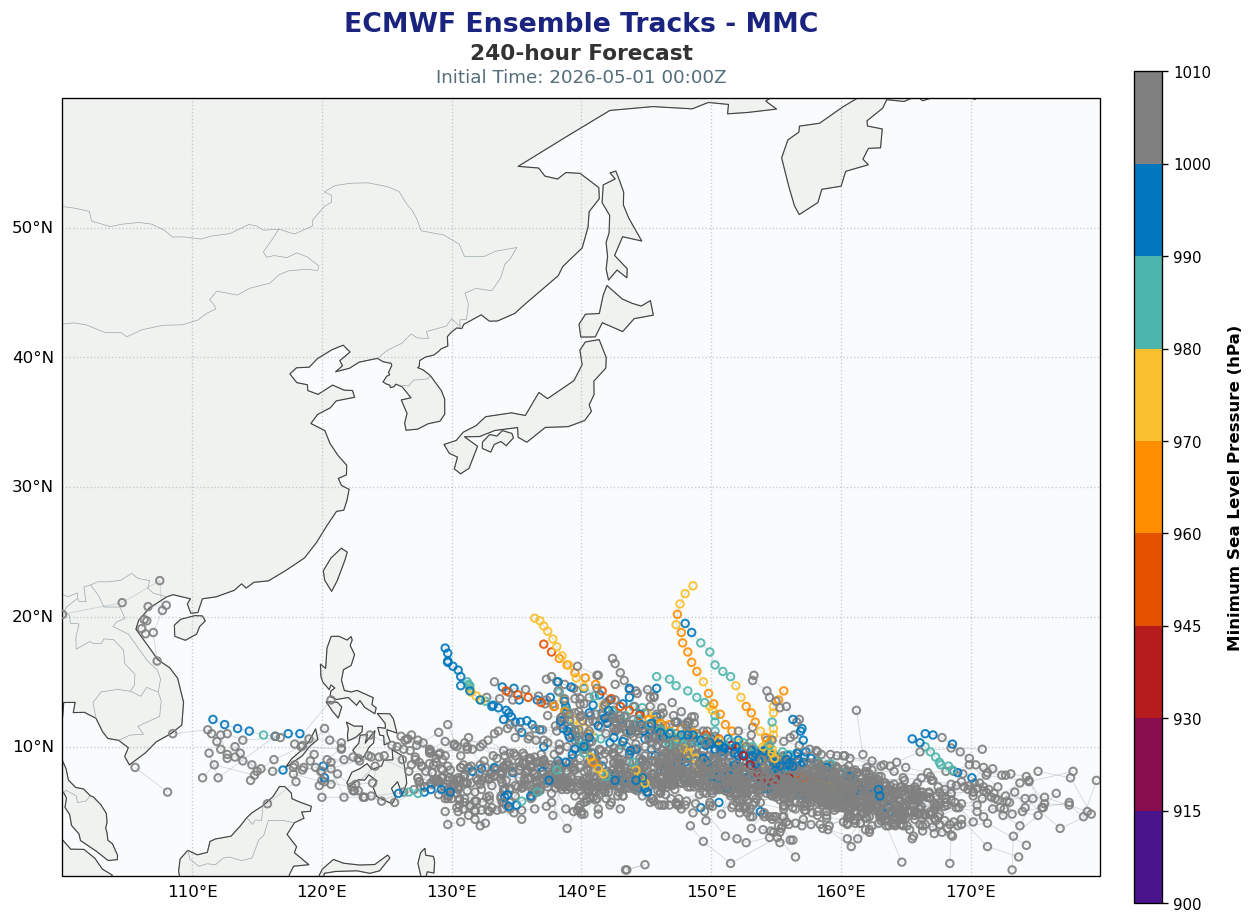

In [6]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from ecmwf.opendata import Client
import earthkit.data

# ====================配置參數區 =======================
init_date = "2026-05-01"  
init_time = 00            
# =====================================================

time_str = f"{init_time:02d}Z"

path = r"C:\Users\andyzhang\Desktop\moweather\Tropical Cyclone 2026\集合預報"
if not os.path.exists(path):
    os.makedirs(path)

target_bufr = os.path.join(path, f"ifs-{init_date}-{time_str}.bufr")
csv_nwp = os.path.join(path, f"ifs-{init_date}-{time_str}-NWP.csv")

client = Client(source="ecmwf")
client.retrieve(
    date=init_date, 
    time=init_time, 
    model="ifs", 
    type="tf", 
    stream="enfo", 
    step=240, 
    target=target_bufr
)

ds = earthkit.data.from_source("file", target_bufr)
df = ds.to_pandas(
    columns=["stormIdentifier", "ensembleMemberNumber", "typicalDate", "typicalTime", 
             "year", "month", "day", "hour", "latitude", "longitude", "pressureReducedToMeanSeaLevel"],
    filters={"meteorologicalAttributeSignificance": 1},
    required_columns=True
)

df = df.dropna(subset=['year', 'month', 'day', 'hour', 'longitude', 'latitude']).copy()

b_date = df['typicalDate'].astype(int).astype(str)
b_time = df['typicalTime'].astype(int).astype(str).str.zfill(4) 
df['base_dt'] = pd.to_datetime((b_date + b_time).str[:12], format='%Y%m%d%H%M')

df['valid_dt'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df['hours'] = (df['valid_dt'] - df['base_dt']).dt.total_seconds() / 3600
df['pressure'] = df['pressureReducedToMeanSeaLevel'] / 100.0

df = df.rename(columns={"stormIdentifier": "track", "ensembleMemberNumber": "sample", 
                        "longitude": "lon", "latitude": "lat"})

df_nwp = df[df['track'].astype(str).str.endswith('W', na=False)].copy()
df_nwp.to_csv(csv_nwp, index=False, encoding='utf-8-sig')

if df_nwp.empty:
    print(f"Warning: No data found for the selected time {init_date} {time_str}")
    sys.exit()

base_time_str = df_nwp['base_dt'].iloc[0].strftime('%Y-%m-%d %H:%MZ')

bounds = [900, 915, 930, 945, 960, 970, 980, 990, 1000, 1010]
colors = [
    '#4a148c', # <915
    '#880e4f', # 915-930
    '#b71c1c', # 930-945
    '#e65100', # 945-960
    '#ff8f00', # 960-970
    '#fbc02d', # 970-980
    '#4db6ac', # 980-990
    '#0277bd', # 990-1000
    '#808080'  # 1000-1010
]

cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

fig = plt.figure(figsize=(12, 9), dpi=120, facecolor='#ffffff')
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([100, 180, 0, 60], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.OCEAN, facecolor='#f9fbfc', zorder=0)
ax.add_feature(cfeature.LAND, facecolor='#f0f2f0', edgecolor='#bcbcbc', linewidth=0.5, zorder=1)
ax.add_feature(cfeature.COASTLINE, linewidth=0.7, edgecolor='#454545', zorder=2)
ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=0.4, edgecolor='#95a5a6', zorder=2)

gl = ax.gridlines(draw_labels=True, linestyle=':', alpha=0.4, color='#7f8c8d', zorder=3)
gl.top_labels = False
gl.right_labels = False

for _, group in df_nwp.groupby(['track', 'sample']):
    ax.plot(group['lon'], group['lat'], color='#546e7a', linewidth=0.5, alpha=0.25, 
            transform=ccrs.PlateCarree(), zorder=4)

sc = ax.scatter(df_nwp['lon'], df_nwp['lat'], 
                edgecolors=cmap(norm(df_nwp['pressure'])), 
                facecolors='none', 
                s=20, 
                linewidths=1.2, 
                alpha=0.9, 
                transform=ccrs.PlateCarree(), zorder=5)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, ax=ax, pad=0.03, fraction=0.04, aspect=30)
cbar.set_label('Minimum Sea Level Pressure (hPa)', fontsize=10, labelpad=10, fontweight='bold')
cbar.ax.tick_params(labelsize=9)

plt.title("ECMWF Ensemble Tracks - MMC", fontsize=16, fontweight='bold', pad=40, color='#1a237e')
plt.text(0.5, 1.05, "240-hour Forecast", 
         transform=ax.transAxes, ha='center', fontsize=13, fontweight='bold', color='#333333')
plt.text(0.5, 1.02, f"Initial Time: {base_time_str}", 
         transform=ax.transAxes, ha='center', fontsize=11, color='#546e7a')

plt.show()